# Disk instability and the stabilising halo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sgpfaff/tambora-docs/blob/master/docs/examples/09-disk-instability.ipynb)

A cold, massive, rotating disk is not a stable object. Left to itself it will
grow a bar within a couple of rotations — one of the most robust results in
galactic dynamics, and the one that produced the first serious argument for
dark matter haloes around disk galaxies.

Ostriker & Peebles (1973) noticed that self-gravitating disks in their
simulations went violently bar-unstable, whereas most real spirals are not
strongly barred. Their proposed resolution was that real disks are embedded in
a massive, hot, roughly spherical component that carries much of the mass but
little of the rotation. That component takes part in the potential without
taking part in the instability, and the bar is suppressed.

This notebook runs both halves of that argument: the same disk, once bare and
once inside a halo, with a quantitative bar strength measured throughout.

**Runtime.** Roughly 12 minutes for both runs at the default resolution, about
90 seconds with `QUICK = True`.

## Setup

In [1]:
# Colab / fresh environment only:
%pip install --pre --quiet "tambora==0.1.0a1" galpy astropy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from galpy import potential
from galpy.potential import DoubleExponentialDiskPotential, NFWPotential

import tambora
from tambora.simulation import Sim
from tambora.tools.util.units import G_KPC_KMS, KPCGYR_TO_KMS

print("tambora", tambora.__version__)

try:
    plt.style.use("../_static/tambora.mplstyle")
except OSError:
    pass

np.random.seed(5)

QUICK = False  # True -> 6000 particles, 1 Gyr

tambora 0.1.0a1


## 1. One disk, two backgrounds

The disk is identical in both runs: same mass, same scale length, same
particles. The only difference is whether an NFW halo is attached as an
external potential.

There is a subtlety in setting this up fairly, and it is the whole experiment.
If we simply *added* a halo to the bare disk, the second run would have a
deeper potential, a faster rotation curve and a different Toomre $Q$ — and any
difference in behaviour could be blamed on any of those. Instead we keep the
**total** rotation curve fixed and vary only how the mass is *divided*: the
bare run puts all the mass in the disk, the halo run keeps a quarter of it there
and makes up the rest with a halo.

"Make up the rest" has to be solved for, not guessed. `NFWPotential(amp=M)` is a
normalisation, not the mass enclosed inside the disk — an NFW with a 12 kpc
scale radius contributes far less inside 6 kpc than its amplitude suggests. So
we solve for the amplitude that restores $v_c$ at a reference radius: circular
speeds add in quadrature and $v_c^2$ scales linearly with mass, so the halo must
supply the deficit $(1-f)\,v_{c,\rm bare}^2$.

In [3]:
M_DISK_FULL = 6.0e10  # mass of the *bare* disk [Msun]
H_R = 3.0  # radial scale length [kpc]
H_Z = 0.25  # vertical scale height [kpc]
R_MAX = 5.0 * H_R
A_HALO = 12.0  # NFW scale radius [kpc]

# Halo run: a quarter of the disk mass stays in the disk, and the halo is sized
# to put the rotation curve back where it was.
DISK_FRACTION = 0.25
R_REF = 2.0 * H_R  # radius at which the two rotation curves are matched

### The disk builder

Same construction as the [ring galaxy example](08-ring-galaxy.ipynb): sample
$\rho \propto e^{-R/h_R}e^{-|z|/h_z}$, then set velocities from the circular
speed, the Toomre $Q$ and asymmetric drift. The difference here is that the
rotation curve is passed in, because it depends on how we split the mass.

In [4]:
# galpy's DoubleExponentialDiskPotential integrates by tanh-sinh quadrature and
# harmlessly overflows in the tails of the transform; the result is fine. Passing
# ro/vo explicitly makes vcirc return km/s as a plain float for a potential list.
def vc_of(pot, R):
    """Circular speed [km/s] at radii R [kpc], quietly."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        return np.array(
            [float(potential.vcirc(pot, float(r) * u.kpc, ro=8.0, vo=220.0)) for r in np.atleast_1d(R)]
        )


def disk_potential(m_disk):
    rho0 = m_disk / (4.0 * np.pi * H_R**2 * H_Z)
    d = DoubleExponentialDiskPotential(
        amp=rho0 * u.Msun / u.kpc**3, hr=H_R * u.kpc, hz=H_Z * u.kpc, ro=8.0, vo=220.0
    )
    d.turn_physical_on()
    return d


def halo_potential(m_halo):
    h = NFWPotential(amp=m_halo * u.Msun, a=A_HALO * u.kpc, ro=8.0, vo=220.0)
    h.turn_physical_on()
    return h


def solve_halo_mass(disk_fraction, r_ref=R_REF):
    """NFW amplitude that restores the bare disk's v_c at r_ref."""
    vc_bare = vc_of(disk_potential(M_DISK_FULL), r_ref)[0]
    vc_thin = vc_of(disk_potential(M_DISK_FULL * disk_fraction), r_ref)[0]
    deficit = vc_bare**2 - vc_thin**2  # what the halo must supply
    trial = 1.0e11
    return trial * deficit / vc_of(halo_potential(trial), r_ref)[0] ** 2


def build_model(m_disk, m_halo):
    """galpy potential for a given disk/halo split, plus grid interpolants."""
    disk_pot = disk_potential(m_disk)
    parts = [disk_pot]
    halo_pot = None
    if m_halo > 0:
        halo_pot = halo_potential(m_halo)
        parts.append(halo_pot)

    # DoubleExponentialDiskPotential is quadrature-based: evaluate on a grid once.
    Rg = np.linspace(0.05, R_MAX * 1.3, 150)
    vcg = vc_of(parts, Rg)
    Og = vcg / Rg
    kg = np.sqrt(np.clip(Rg * np.gradient(Og**2, Rg) + 4.0 * Og**2, 1e-12, None))
    return disk_pot, halo_pot, (Rg, vcg, Og, kg)


def make_disk(n, m_disk, grids, Q=1.2, seed=0):
    """Sample the disk in centrifugal + epicyclic equilibrium."""
    Rg, vcg, Og, kg = grids
    r = np.random.default_rng(seed)

    RR = np.linspace(0.0, R_MAX, 4000)
    cdf = 1.0 - (1.0 + RR / H_R) * np.exp(-RR / H_R)
    cdf /= cdf[-1]
    R = np.interp(r.random(n), cdf, RR)

    phi = r.uniform(0.0, 2.0 * np.pi, n)
    z = np.where(r.random(n) < 0.5, -1.0, 1.0) * (-H_Z * np.log(r.random(n)))
    pos = np.column_stack([R * np.cos(phi), R * np.sin(phi), z])

    vc = np.interp(R, Rg, vcg)
    Om = np.interp(R, Rg, Og)
    ka = np.interp(R, Rg, kg)

    Sigma = m_disk / (2.0 * np.pi * H_R**2) * np.exp(-R / H_R)
    sigma_R = Q * 3.36 * G_KPC_KMS * Sigma / ka
    sigma_phi = sigma_R * ka / (2.0 * Om)
    sigma_z = np.sqrt(2.0 * np.pi * G_KPC_KMS * Sigma * H_Z)

    drift = sigma_R**2 * (1.0 - ka**2 / (4.0 * Om**2) - 2.0 * R / H_R)
    v_phi = np.sqrt(np.clip(vc**2 + drift, 0.0, None)) + r.normal(0.0, sigma_phi)
    v_R = r.normal(0.0, sigma_R)

    vel = np.column_stack(
        [
            v_R * np.cos(phi) - v_phi * np.sin(phi),
            v_R * np.sin(phi) + v_phi * np.cos(phi),
            r.normal(0.0, sigma_z),
        ]
    )
    # Sampling leaves a net momentum of order sigma/sqrt(N) -- about 0.4 km/s
    # here, which is small until you notice it walks the whole disk ~1 kpc off
    # the plane over 2 Gyr and looks exactly like real vertical evolution.
    # Subtract it, and re-centre, so the disk starts at rest at the origin.
    pos -= pos.mean(axis=0)
    vel -= vel.mean(axis=0)
    return pos, vel, np.full(n, m_disk / n)

## 2. The bar strength diagnostic

"It looks barred" is not a measurement. The standard diagnostic is the
normalised $m = 2$ Fourier amplitude of the surface density,

$$ A_2(t) \;=\; \frac{\left|\sum_j m_j\, e^{2i\phi_j}\right|}{\sum_j m_j}, $$

evaluated over the particles in the disk region. An axisymmetric disk gives
$A_2 \approx 0$ (up to shot noise of order $1/\sqrt{N}$); a strong bar gives
$A_2 \gtrsim 0.3$.

The *phase* of the same complex number is the bar's orientation, so its time
derivative is the pattern speed — free of charge.

In [5]:
def bar_amplitude(x, y, mass, r_max=None):
    """Return (A_2, phase) for the m=2 Fourier mode."""
    R = np.hypot(x, y)
    sel = R < (r_max if r_max is not None else np.inf)
    sel &= R > 0.0
    if sel.sum() == 0:
        return 0.0, 0.0
    c = np.sum(mass[sel] * np.exp(2j * np.arctan2(y[sel], x[sel])))
    return np.abs(c) / mass[sel].sum(), 0.5 * np.angle(c)

We also want the Ostriker–Peebles ratio,

$$ t \;=\; \frac{T_{\rm rot}}{|W|}, $$

the fraction of the binding energy carried by *ordered rotation*. Their
empirical result was that disks with $t \gtrsim 0.14$ go bar-unstable. Note
that $T_{\rm rot}$ uses only the mean streaming motion — random motions are
pressure, not rotation, and pressure is stabilising.

In [6]:
def ostriker_peebles(sim_obj, comp, t_idx, n_bins=30):
    """T_rot / |W| for one component, with T_rot from the mean streaming only."""
    c = getattr(sim_obj, comp)
    x, y = c.x(t=t_idx), c.y(t=t_idx)
    vx, vy = c.vx(t=t_idx), c.vy(t=t_idx)
    m = c.mass

    R = np.hypot(x, y)
    v_phi = (x * vy - y * vx) / np.clip(R, 1e-9, None)

    # Mean streaming speed in radial annuli, so random motion is excluded.
    edges = np.linspace(0.0, R.max(), n_bins + 1)
    idx = np.clip(np.digitize(R, edges) - 1, 0, n_bins - 1)
    mean_vphi = np.zeros(n_bins)
    for b in range(n_bins):
        in_b = idx == b
        if in_b.any():
            mean_vphi[b] = np.average(v_phi[in_b], weights=m[in_b])

    T_rot = 0.5 * np.sum(m * mean_vphi[idx] ** 2)
    # |W| must be the TOTAL binding energy. The halo is a rigid external field,
    # so it contributes m*Phi_ext with no factor of a half (there is no
    # halo-halo self-energy here). Leaving it out inflates T_rot/|W| for the
    # halo run and reverses the comparison -- the disk there is only a quarter
    # of the mass, so its self-energy alone is tiny.
    # compute_external_pot returns m*Phi_ext per particle, and is simply zero
    # when no external force is attached, so this is safe for the bare run too.
    W = 0.5 * sim_obj.self_potential(t=t_idx).sum()
    W += sim_obj.compute_external_pot(t=t_idx).sum()
    return T_rot / abs(W)

## 3. Run both cases

`method="falcON"` for the self-gravity in both. The halo run adds the NFW as an
external potential; the bare run has no external force at all.

In [7]:
N = 6000 if QUICK else 25000
T_END = 1.0 if QUICK else 2.0
DT = 2.5e-4
DT_OUT = 1e-2
EPS = 0.10  # kpc; below h_z, but large enough to keep the drift sane
Q0 = 1.2  # cold enough to be unstable


def run_case(name, disk_fraction):
    """Build and run one disk. disk_fraction=1.0 is the bare case."""
    m_disk = M_DISK_FULL * disk_fraction
    m_halo = 0.0 if disk_fraction >= 1.0 else solve_halo_mass(disk_fraction)

    disk_pot, halo_pot, grids = build_model(m_disk, m_halo)
    pos, vel, mass = make_disk(N, m_disk, grids, Q=Q0, seed=5)

    s = Sim()
    s.add_particles("disk", pos, vel, mass)
    if halo_pot is not None:
        s.add_external_pot(halo_pot)

    print(f"\n=== {name} ===")
    print(f"M_disk = {m_disk:.2e} Msun, M_halo = {m_halo:.2e} Msun")
    s.run(t_end=T_END, dt=DT, dt_out=DT_OUT, eps=EPS, theta=0.6)
    print(f"|dE/E0| = {s.monitor.drift['energy'][-1]:.2e}")
    return s


sim_bare = run_case("bare disk", 1.0)
sim_halo = run_case("disk + halo", DISK_FRACTION)

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora-docs/67f2c9a1-fd52-4fb9-a988-3ccca0e9a3dc/scratchpad/tamboraenv/lib/python3.13/site-packages/galpy/potential/DoubleExponentialDiskPotential.py:19: RuntimeWarning: overflow encountered in sinh
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora-docs/67f2c9a1-fd52-4fb9-a988-3ccca0e9a3dc/scratchpad/tamboraenv/lib/python3.13/site-packages/galpy/potential/DoubleExponentialDiskPotential.py:20: RuntimeWarning: overflow encountered in cosh
  numpy.cosh(numpy.pi * numpy.sinh(t)) + 1

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora-docs/67f2c9a1-fd52-4fb9-a988-3ccca0e9a3dc/scratchpad/tamboraenv/lib/python3.13/site-packages/galpy/potential/DoubleExponentialDiskPotential.py:19: RuntimeWarning: invalid value encountered in divide
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (


=== bare disk ===
M_d

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 7/8000 [00:00<02:06, 63.26it/s, |dE/E0|=0.00e+00]

  0%|          | 15/8000 [00:00<01:54, 69.46it/s, |dE/E0|=0.00e+00]

  0%|          | 23/8000 [00:00<01:52, 71.17it/s, |dE/E0|=0.00e+00]

...

100%|█████████▉| 7986/8000 [01:59<00:00, 67.01it/s, |dE/E0|=6.78e-06]

100%|█████████▉| 7993/8000 [01:59<00:00, 67.08it/s, |dE/E0|=6.78e-06]

100%|██████████| 8000/8000 [01:59<00:00, 67.08it/s, |dE/E0|=6.85e-06]

100%|██████████| 8000/8000 [01:59<00:00, 66.83it/s, |dE/E0|=6.85e-06]

|dE/E0| = 6.85e-06


### Check the two runs really did start equivalent

Before reading anything into the difference, confirm the setup was fair: the
rotation curves should agree, because that is what we solved for.

They agree closely across the inner disk and then part company beyond
$\sim 8$ kpc — an NFW simply cannot reproduce an exponential disk's *declining*
curve, so a one-parameter match cannot hold everywhere. That is acceptable
here because the bar forms well inside $R_{\rm ref}$, but it is the kind of
thing to state rather than gloss over: the two runs are matched where the
physics happens, not globally.

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora-docs/67f2c9a1-fd52-4fb9-a988-3ccca0e9a3dc/scratchpad/tamboraenv/lib/python3.13/site-packages/galpy/potential/DoubleExponentialDiskPotential.py:19: RuntimeWarning: overflow encountered in sinh
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora-docs/67f2c9a1-fd52-4fb9-a988-3ccca0e9a3dc/scratchpad/tamboraenv/lib/python3.13/site-packages/galpy/potential/DoubleExponentialDiskPotential.py:20: RuntimeWarning: overflow encountered in cosh
  numpy.cosh(numpy.pi * numpy.sinh(t)) + 1

/private/tmp/claude-501/-Users-gabrielpfaffman-Repos-tambora-docs/67f2c9a1-fd52-4fb9-a988-3ccca0e9a3dc/scratchpad/tamboraenv/lib/python3.13/site-packages/galpy/potential/DoubleExponentialDiskPotential.py:19: RuntimeWarning: invalid value encountered in divide
  return (numpy.sinh(numpy.pi * numpy.sinh(t)) + numpy.pi * t * numpy.cosh(t)) / (

/private/tmp/claude-50

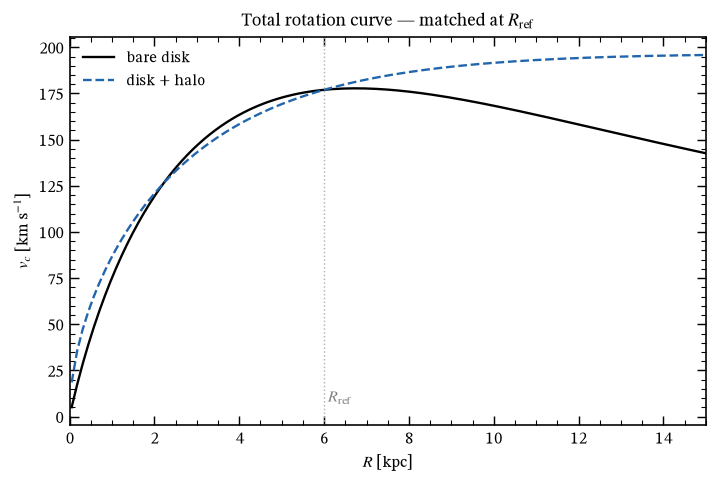

In [8]:
Rg = np.linspace(0.3, R_MAX, 60)
_, _, g_bare = build_model(M_DISK_FULL, 0.0)
_, _, g_halo = build_model(M_DISK_FULL * DISK_FRACTION, solve_halo_mass(DISK_FRACTION))

fig, ax = plt.subplots(figsize=(5.6, 3.8))
ax.plot(g_bare[0], g_bare[1], "k", label="bare disk")
ax.plot(g_halo[0], g_halo[1], c="#2166ac", ls="--", label="disk + halo")
ax.set_xlabel("$R$ [kpc]")
ax.set_ylabel("$v_c$ [km s$^{-1}$]")
ax.axvline(R_REF, c="0.7", lw=0.8, ls=":")
ax.text(R_REF, 8, " $R_{\\rm ref}$", color="0.5", fontsize=9)
ax.set_title("Total rotation curve — matched at $R_{\\rm ref}$")
ax.set_xlim(0, R_MAX)
ax.legend()
fig.tight_layout()
plt.show()

## 4. What happened

Face-on, at four times each. The bare disk should be unmistakable.

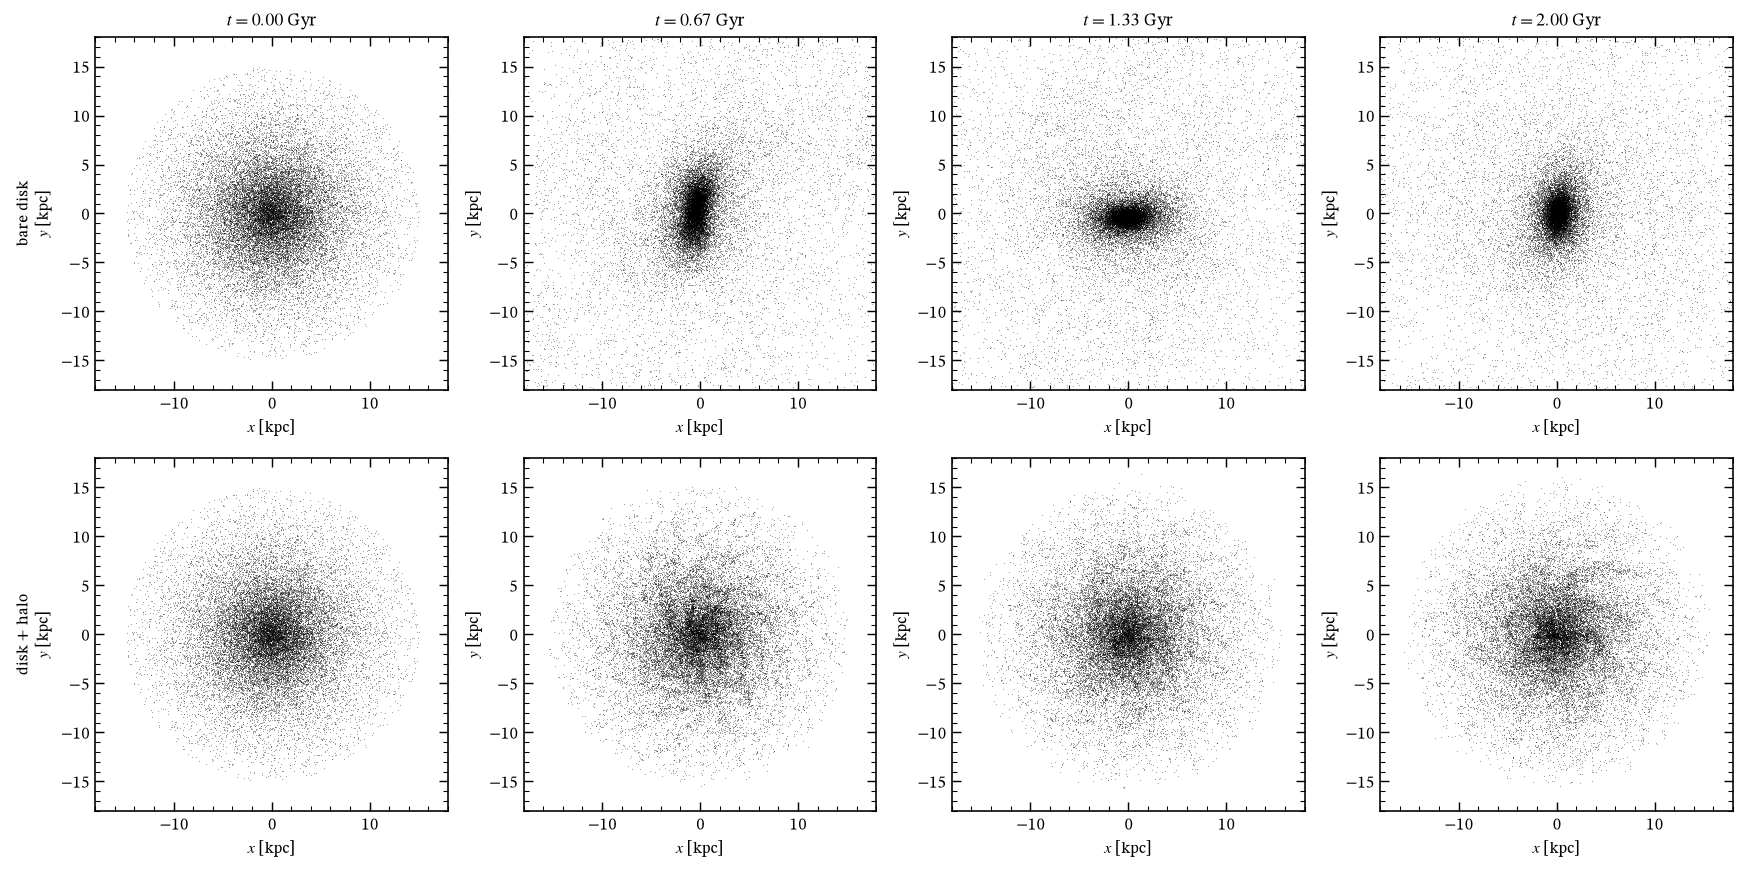

In [9]:
t_show = np.linspace(0.0, sim_bare.times[-1], 4)
fig, axes = plt.subplots(2, 4, figsize=(13.5, 6.8))

for row, (s, label) in enumerate([(sim_bare, "bare disk"), (sim_halo, "disk + halo")]):
    for col, t in enumerate(t_show):
        ax = axes[row, col]
        ax.scatter(s.disk.x(t=float(t)), s.disk.y(t=float(t)),
                   s=0.4, lw=0, c="k", alpha=0.4)
        ax.set_xlim(-18, 18)
        ax.set_ylim(-18, 18)
        ax.set_aspect("equal")
        ax.set_xlabel("$x$ [kpc]")
        if col == 0:
            ax.set_ylabel(f"{label}\n$y$ [kpc]")
        else:
            ax.set_ylabel("$y$ [kpc]")
        if row == 0:
            ax.set_title(f"$t = {t:.2f}$ Gyr")

fig.tight_layout()
plt.show()

## 5. Bar strength against time

The measurement, rather than the impression.

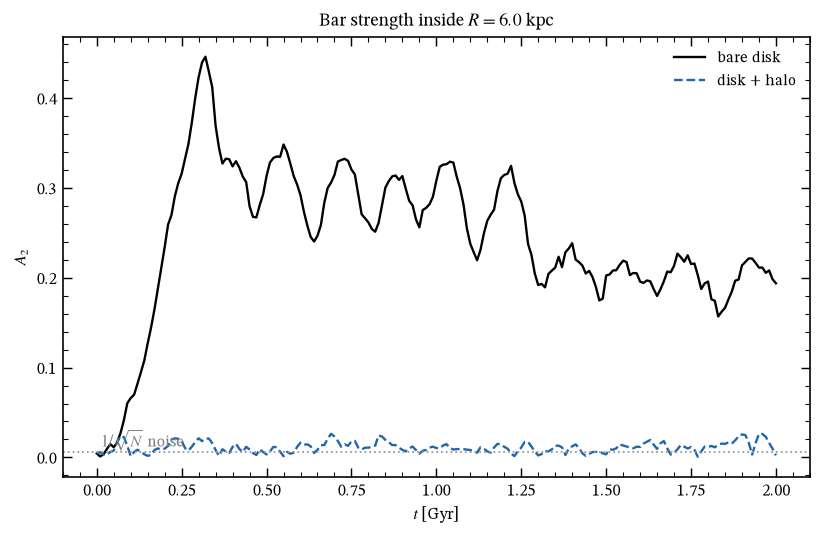

bare disk      A_2: start 0.004  peak 0.446  end 0.194
disk + halo    A_2: start 0.004  peak 0.026  end 0.002


In [10]:
R_BAR = 2.0 * H_R  # measure the mode inside the disk's inner region

A2 = {}
phase = {}
for label, s in [("bare disk", sim_bare), ("disk + halo", sim_halo)]:
    a, p = [], []
    for i in range(len(s.times)):
        ai, pi = bar_amplitude(s.disk.x(t=i), s.disk.y(t=i), s.disk.mass, r_max=R_BAR)
        a.append(ai)
        p.append(pi)
    A2[label] = np.array(a)
    phase[label] = np.unwrap(2 * np.array(p)) / 2

noise = 1.0 / np.sqrt(N)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot(sim_bare.times, A2["bare disk"], "k", label="bare disk")
ax.plot(sim_halo.times, A2["disk + halo"], c="#2166ac", ls="--", label="disk + halo")
ax.axhline(noise, c="0.6", ls=":", lw=1.0)
ax.text(sim_bare.times[0], noise, r" $1/\sqrt{N}$ noise", color="0.5",
        va="bottom", ha="left", fontsize=9)
ax.set_xlabel("$t$ [Gyr]")
ax.set_ylabel("$A_2$")
ax.set_title(f"Bar strength inside $R = {R_BAR:.1f}$ kpc")
ax.legend()
fig.tight_layout()
plt.show()

for label in A2:
    print(f"{label:14s} A_2: start {A2[label][0]:.3f}  peak {A2[label].max():.3f}  "
          f"end {A2[label][-1]:.3f}")

## 6. The instability in motion

The two runs side by side, with the measurement tracking alongside:

- **Bare disk** — a two-armed spiral winds up within a couple of rotations and
  closes into a bar, which then rotates as a solid body.
- **Disk + halo** — for comparison. Nothing happens, which is the entire point.
- **$A_2(t)$** — with a marker on the current frame, so you can match what the
  bar looks like to what the diagnostic says.

$A_2$ peaks near $t \approx 0.3$ Gyr and then declines. Two things are going on,
and it is worth separating them.

The bar is saturating: it transfers angular momentum outward and converts
ordered rotation into random motion, which is what limits its own growth.

There is also a vertical event. Measure the bar region ($R < 4$ kpc) and it
thickens from about 170 pc to 430 pc, fastest around $t \approx 0.76$ Gyr, with
a *transient* bending asymmetry — the mean height of the bar region swings up
to ~85 pc near $t \approx 0.8$ Gyr and then relaxes back toward zero. That is
the signature of a **buckling** instability: the bar bends out of the plane,
then settles into a thicker, peanut-shaped remnant. It is much weaker here
than in the textbook picture, and it is not obvious by eye in the face-on
view, so treat it as something this run hints at rather than demonstrates.

:::{admonition} Measure it before you believe it
:class: warning

An earlier version of this notebook reported the bar region thickening to over
a kiloparsec. Almost all of that was an artefact: sampling $N$ velocities from
a dispersion $\sigma$ leaves a net momentum of order $\sigma/\sqrt{N}$, and left
in place that walks the entire disk off the plane by ~1 kpc over 2 Gyr. It
looks exactly like vertical evolution. `make_disk` now subtracts the net
momentum, and the real thickening is a third of the apparent one. If you write
your own IC sampler, subtract the mean — and check $\langle z \rangle$
separately from $\langle |z| \rangle$, because only the second is thickening.
:::

60 frames, 4.5 MB


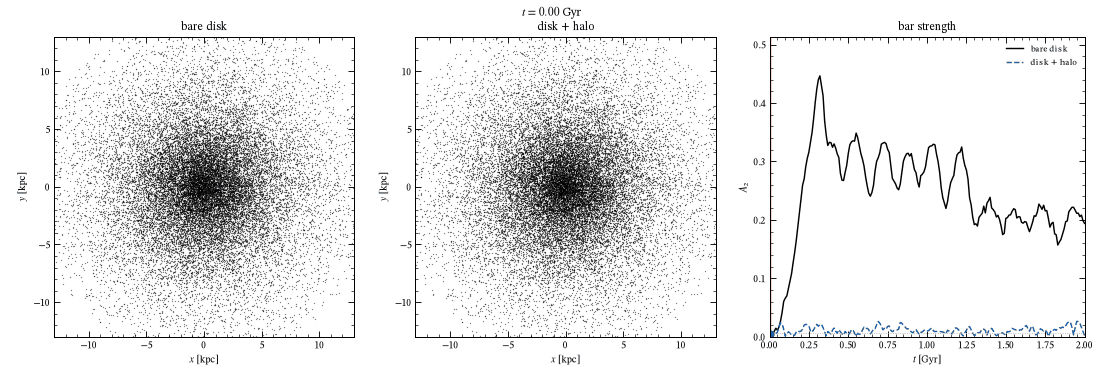

In [11]:
from IPython.display import Image  # noqa: E402
from matplotlib.animation import FuncAnimation, PillowWriter  # noqa: E402

t_anim = np.linspace(0.0, sim_bare.times[-1], 60)
idx_anim = np.searchsorted(sim_bare.times, t_anim).clip(0, len(sim_bare.times) - 1)

LIM = 13.0  # zoom in: the interesting structure is all well inside this
fig, (ax_bf, ax_hf, ax_a2) = plt.subplots(1, 3, figsize=(13.8, 4.7))

# Bigger, darker points than a static figure would use. A scatter that reads
# fine at full page size turns into invisible dust once it is a GIF frame.
sc_bf = ax_bf.scatter([], [], s=1.4, lw=0, c="k", alpha=0.5)
ax_bf.set_xlabel("$x$ [kpc]")
ax_bf.set_ylabel("$y$ [kpc]")
ax_bf.set_title("bare disk")

sc_hf = ax_hf.scatter([], [], s=1.4, lw=0, c="k", alpha=0.5)
ax_hf.set_xlabel("$x$ [kpc]")
ax_hf.set_ylabel("$y$ [kpc]")
ax_hf.set_title("disk + halo")

for ax in (ax_bf, ax_hf):
    ax.set_xlim(-LIM, LIM)
    ax.set_ylim(-LIM, LIM)
    ax.set_aspect("equal")

# The A_2 curves are already computed, so draw them once and just move a marker.
ax_a2.plot(sim_bare.times, A2["bare disk"], "k", lw=1.3, label="bare disk")
ax_a2.plot(sim_halo.times, A2["disk + halo"], c="#1a5fa8", ls="--", lw=1.3,
           label="disk + halo")
ax_a2.axhline(noise, c="0.7", ls=":", lw=0.8)
(vline,) = ax_a2.plot([], [], c="#d94801", lw=1.3)
(dot_b,) = ax_a2.plot([], [], "o", c="k", ms=6)
(dot_h,) = ax_a2.plot([], [], "o", c="#1a5fa8", ms=6)
ax_a2.set_xlim(0, sim_bare.times[-1])
ax_a2.set_ylim(0, max(A2["bare disk"]) * 1.15)
ax_a2.set_xlabel("$t$ [Gyr]")
ax_a2.set_ylabel("$A_2$")
ax_a2.set_title("bar strength")
ax_a2.legend(fontsize=8, loc="upper right")

ttl = fig.suptitle("")
fig.tight_layout()


def update(k):
    i = int(idx_anim[k])
    sc_bf.set_offsets(np.c_[sim_bare.disk.x(t=i), sim_bare.disk.y(t=i)])
    sc_hf.set_offsets(np.c_[sim_halo.disk.x(t=i), sim_halo.disk.y(t=i)])
    t = sim_bare.times[i]
    vline.set_data([t, t], [0, ax_a2.get_ylim()[1]])
    dot_b.set_data([t], [A2["bare disk"][i]])
    dot_h.set_data([t], [A2["disk + halo"][i]])
    ttl.set_text(f"$t = {t:.2f}$ Gyr")
    return sc_bf, sc_hf, vline, dot_b, dot_h, ttl


anim = FuncAnimation(fig, update, frames=range(len(idx_anim)), blit=False)
anim.save("disk_instability.gif", writer=PillowWriter(fps=6), dpi=80)
plt.close(fig)

from PIL import Image as PILImage, ImageSequence  # noqa: E402

_src = PILImage.open("disk_instability.gif")
_fr = [f.copy().convert("RGB").quantize(colors=64, method=PILImage.MEDIANCUT)
       for f in ImageSequence.Iterator(_src)]
# duration is the per-frame delay in ms, and it -- not the writer's fps -- is
# what the viewer actually sees. 180 ms is a comfortable pace for this.
_fr[0].save("disk_instability.gif", save_all=True, append_images=_fr[1:],
            duration=180, loop=0, optimize=True)
print(f"{len(_fr)} frames, "
      f"{__import__('os').path.getsize('disk_instability.gif') / 1e6:.1f} MB")

Image(filename="disk_instability.gif")

## 7. The Ostriker–Peebles number

Evaluated at $t = 0$, this is a *prediction* rather than a description: it is
computed from the initial conditions alone, before either disk has done
anything.

In [12]:
for label, s in [("bare disk", sim_bare), ("disk + halo", sim_halo)]:
    t0 = ostriker_peebles(s, "disk", 0)
    t1 = ostriker_peebles(s, "disk", len(s.times) - 1)
    verdict = "unstable" if t0 > 0.14 else "stable"
    print(f"{label:14s} t(0) = {t0:.3f}  ({verdict})   t(end) = {t1:.3f}")

bare disk      t(0) = 0.288  (unstable)   t(end) = 0.125
disk + halo    t(0) = 0.090  (stable)   t(end) = 0.089


For the bare disk essentially all of the binding energy is supplied by a
rotating component, so $t$ sits well above the 0.14 threshold.

The halo run cuts $T_{\rm rot}/|W|$ from both ends at once. The numerator only
counts *ordered rotation*, and the halo has none — it is a static field. The
denominator, though, gains the halo's full contribution to the binding energy.
Note how lopsided that is in practice: the disk drops to a quarter of its
original mass, but the halo needed to restore $v_c$ is an order of magnitude
more massive than the disk ever was, because an NFW spreads its mass far
beyond the disk. Most of the binding energy now comes from something that does
not rotate, and $t$ falls below the threshold.

Note also how $t$ *falls* over the bare run. That is the bar doing its job — it
transports angular momentum outward and converts ordered rotation into random
motion, which is precisely the mechanism that eventually saturates the
instability.

## 8. The pattern speed

The bar rotates as a solid body, much more slowly than the stars in it. The
phase of $A_2$ gives $\Omega_p$ directly.

pattern speed Omega_p = 22.2 km/s/kpc
corotation radius     = 7.93 kpc
bar 'fast' if R_cr / R_bar < 1.4 : R_cr / 6.0 = 1.32


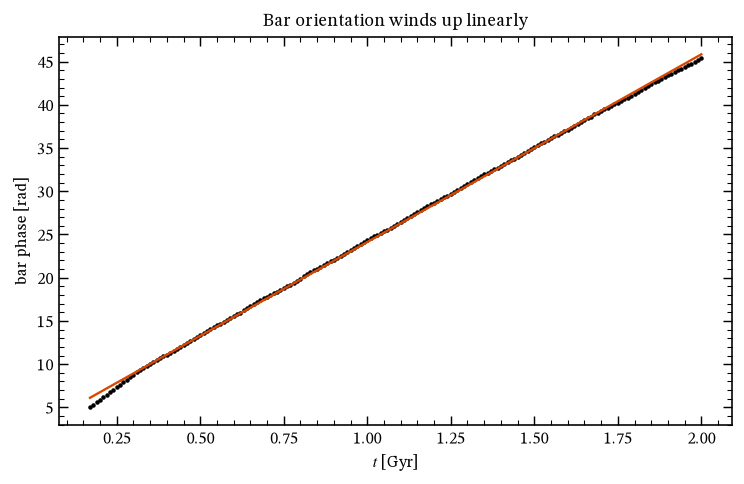

In [13]:
fit = A2["bare disk"] > 0.15  # only where a bar actually exists
if fit.sum() > 5:
    t_fit = sim_bare.times[fit]
    ph_fit = phase["bare disk"][fit]
    slope = np.polyfit(t_fit, ph_fit, 1)[0]  # rad/Gyr
    Omega_p = abs(slope) / KPCGYR_TO_KMS  # rad/Gyr -> km/s/kpc
    print(f"pattern speed Omega_p = {Omega_p:.1f} km/s/kpc")

    R_cr = np.interp(Omega_p, g_bare[2][::-1], g_bare[0][::-1])
    print(f"corotation radius     = {R_cr:.2f} kpc")
    print(f"bar 'fast' if R_cr / R_bar < 1.4 : R_cr / {R_BAR:.1f} = "
          f"{R_cr / R_BAR:.2f}")

    fig, ax = plt.subplots(figsize=(5.8, 3.8))
    ax.plot(t_fit, ph_fit, "k.", ms=3)
    ax.plot(t_fit, np.polyval(np.polyfit(t_fit, ph_fit, 1), t_fit), c="#d94801")
    ax.set_xlabel("$t$ [Gyr]")
    ax.set_ylabel("bar phase [rad]")
    ax.set_title("Bar orientation winds up linearly")
    fig.tight_layout()
    plt.show()
else:
    print("no sustained bar to fit a pattern speed to")

## 9. Caveats worth carrying forward

- **The halo is rigid.** A live halo can absorb the angular momentum the bar
  sheds, which in real simulations lets the bar grow *stronger* and slow down
  over time. A rigid halo cannot, so this experiment overstates the
  suppression. The Ostriker–Peebles argument survives, but "haloes prevent
  bars" is too strong a reading of it — the modern picture is that haloes
  change the bar's growth rate and its later evolution.
- **$Q$ and the mass split are the knobs.** $Q_0 = 1.2$ is deliberately cold.
  Warm the disk to $Q \sim 2$ and even the bare case takes far longer to form a
  bar. It is worth re-running with a few values to see the threshold behaviour
  rather than taking one pair of runs as the result.
- **Resolution matters for the noise floor.** $A_2$ has a shot-noise floor of
  about $1/\sqrt{N}$, drawn on the figure. Any claimed bar below that line is
  not a bar.
- **Two runs are an anecdote.** The honest version of this experiment scans
  disk fraction and $Q$ on a grid.

## Summary

- Vary *one* thing. Holding $v_c(R)$ fixed while moving mass between disk and
  halo is what makes the comparison mean anything.
- $A_2$ is the bar measurement; $1/\sqrt{N}$ is its noise floor.
- $T_{\rm rot}/|W| > 0.14$ predicts instability from the ICs alone, and the
  ratio falls as the bar transfers angular momentum outward.
- The phase of $A_2$ gives the pattern speed and hence the corotation radius.